
# IND320 — Project work, part 1

## Lenker
- GitHub-repo: https://github.com/malikaaebo-cell/IND320_prosjekt
- Streamlit-app: https://malikaaebo-cell-ind320-prosjekt-main-rqsvdg.streamlit.app

<div class="alert alert-block alert-info">
<h2>AI bruk</h2>

Jeg har brukt Claude som støtte gjennom arbeidet med denne innleveringen.

- **Feilsøking og feilmeldinger:** Claude hjalp meg med å tolke feilmeldinger og finne årsaker, blant annet en korrupt plotly-installasjon, en diskplass-feil som hindret pakkeinstallasjon og NumPy-feilen som skyldtes en gammel Anaconda-Python 3.8. Det virtuelle miljøet ble til slutt bygget på nytt med Python 3.12.
- **Veiledning i verktøyene:** generell hjelp med VS Code (kernel-valg, virtuelle miljøer og Jupyter-oppsett), Git og .gitignore.
- **Sortering og håndtering av datasettet:** Claude pekte på at datasettet har ni områder som ikke kan sorteres på dato alene, og foreslo å sortere på område og dato og plotte ett område om gangen.
- **Tolkning av eksempler:** Claude hjalp meg med å forstå eksempelkoder fra kursmaterialet og dokumentasjonen.
- **Formulering:** Claude hjalp meg med å skrive kildelisten min, slik at den ble strukturert mer oversiktlig.

</div>

<div class="alert alert-block alert-success">
<h2>Logg</h2>

Jeg startet med å opprette en GitHub-konto og et offentlig repository, og koblet det til Streamlit Community Cloud for å få en enkel app til å kjøre (minimum working example). Som øvelse laget jeg først en Collatz-app, der jeg lærte session_state og arbeidsflyten mellom VS Code, Git og Streamlit Cloud. Siden dette lå i samme mappe som kursmaterialet, flyttet jeg senere prosjektet til et eget, rent repository.

I Jupyter Notebook leste jeg inn reservoirs.csv med pandas og døpte om de norske kolonnenavnene til engelske med rename(). info() og describe() viste at datoen ble lest inn som tekst, og at kolonnene har svært ulike skalaer, for eksempel en fyllingsgrad mellom 0 og 1 og en kapasitet på opptil 87 TWh. Datasettet inneholder dessuten ni områder (EL 1-5, VASS 1-3 og NO 0) med én rad per uke hver, til sammen 1653 uker fra januar 1995 til september 2026.

De første plottene så kaotiske ut. Årsaken var at radene ikke lå i noen bestemt rekkefølge, og at de ni områdene ble blandet i samme kurve. Sortering på dato alene hjalp ikke, siden det gir ni tilfeldige verdier per uke. Løsningen var å konvertere datoen, lage en områdeetikett og sortere på område og dato, og deretter plotte ett område om gangen med dato på x-aksen. For å vise alle kolonnene sammen skalerte jeg hver kolonne til 0-1 innenfor området, og satte kolonner som aldri endrer seg (som kapasiteten) til 0. Plottet viser et tydelig sesongmønster i magasinfyllingen.

Streamlit-appen har fire sider: forsiden, en tabellside, en plottside og en side med placeholder-innhold. Sidemenyen lages automatisk fra pages-mappen. Tabellsiden har én rad per kolonne i datasettet, med LineChartColumn som viser første måned, og en nedtrekksmeny for område. Plottsiden har nedtrekksmenyer for område og kolonne (én eller alle) og en select_slider for måneder, med første måned som standard. Dataene leses av en felles funksjon med @st.cache_data, slik at CSV-filen bare leses én gang.

Den største tekniske utfordringen var det virtuelle miljøet. Det var bygget på en gammel Python 3.8 fra Anaconda, og NumPy ble ufullstendig installert (ImportError for _multiarray_umath). Å installere pakkene på nytt hjalp ikke, siden grunnlaget var det samme. Etter feilsøking laget jeg et nytt miljø med Python 3.12 og installerte bare pakkene prosjektet trenger. Jeg lærte å sjekke Python-versjon og aktivt miljø (python --version, which python) og å holde .venv utenfor GitHub med .gitignore.

Noen valg jeg tok: Oppgaven ber om én rad per kolonne i det importerte datasettet, så alle 11 kolonner fra reservoirs.csv er med i tabellen. Tekst- og datokolonnene (date, area_type og next_publication_date) kan ikke tegnes som linjer og har derfor en tom celle. Oppgaven nevner ikke at datasettet har ni områder. Uten et valg ville første måned blandet områdene, så jeg la til en nedtrekksmeny for område på både tabell- og plottsiden. Da viser hver linje og hvert plott én sammenhengende serie.

Til koden hentet jeg inspirasjon fra kursmaterialet (blant annet blank_canvas.py, caching.py og 4_Streamlit.ipynb), fra foreleserens eksempelrepo og fra dokumentasjonen til pandas, Matplotlib og Streamlit. Kildene er listet under «Kilder».
</div>

<div class="alert alert-block alert-danger">
<h2>Kilder</h2>

**Prosjektstruktur og publisering**

- **Organisering av prosjektmappen:** brukt som mal for hvordan et Streamlit-prosjekt kan struktureres med egne mapper for sider (pages/), delt kode (modules/) og notebook (notebooks/), siden oppgaveteksten ikke spesifiserer en konkret struktur. Kilde: [github.com/khliland/ind320_student](https://github.com/khliland/ind320_student)
- **Publisering av appen på nett:** fulgt fra 4_Streamlit.ipynb (kursnotebook) for å koble GitHub-repoet til Streamlit Community Cloud og få appen til å kjøre på en offentlig URL.

**Streamlit-sidene**

- **Enkel tekstvisning på sidene:** inspirert av blank_canvas.py (kurseksempel), brukt for tittel og beskrivende tekst øverst på hver side i appen.
- **Rask innlasting av data i appen:** inspirert av caching.py (kurseksempel), brukt for å unngå at CSV-filen leses på nytt ved hver interaksjon, som oppgaven krever for hastighet.
- **Minigraf per rad i tabellen:** brukt for å vise en trendlinje for hver kolonne på tabellsiden, som oppgaven eksplisitt ber om. Kilde: [Streamlit-dokumentasjon for LineChartColumn](https://docs.streamlit.io/develop/api-reference/data/st.column_config/st.column_config.linechartcolumn)
- **Valg av tidsrom i plottet:** brukt til å la brukeren velge måneder å vise på plottsiden, siden select_slider bare er nevnt i kurset, uten eksempel. Kilde: [Streamlit-dokumentasjon for select_slider](https://docs.streamlit.io/develop/api-reference/widgets/st.select_slider)
- **Gruppering av datoer til måneder:** brukt for å gjøre periodevelgeren månedsbasert i stedet for å vise hver enkelt dato. Kilde: [Pandas-dokumentasjon for dt.to_period()](https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.to_period.html)

**Data og plotting i notebooken**

- **Oversettelse av kolonnenavn til engelsk:** brukt for å gi de norske kolonnenavnene i reservoirs.csv forståelige engelske navn, som oppgaven krever. Kilde: [Pandas-dokumentasjon for rename()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html)
- **Filtrering til kun tallkolonner før plotting:** brukt for å automatisk hoppe over tekstkolonner (som dato) ved plotting, slik at de ikke gir feil. Kilde: [Pandas-dokumentasjon for select_dtypes()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.select_dtypes.html)
- **Plotting av datasettet:** brukt som grunnlag for å plotte hver kolonne separat og alle kolonner sammen i notebooken. Kilde: [Matplotlib pyplot-eksempel](https://matplotlib.org/stable/gallery/pyplots/pyplot_simple.html)
</div>

In [13]:
# Read the reservoirs.csv file
import pandas as pd
df = pd.read_csv('../project_data/reservoirs.csv')
print(df.shape)
# Show the original (Norsk) column names
print(df.columns.tolist())
df.head()


(14877, 11)
['dato_Id', 'omrType', 'omrnr', 'iso_aar', 'iso_uke', 'fyllingsgrad', 'kapasitet_TWh', 'fylling_TWh', 'neste_Publiseringsdato', 'fyllingsgrad_forrige_uke', 'endring_fyllingsgrad']


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [18]:
# Gi kolonnene forståelige, engelske navn
df = df.rename(columns={
    'dato_Id': 'date',
    'omrType': 'area_type',
    'omrnr': 'area_number',
    'iso_aar': 'iso_year',
    'iso_uke': 'iso_week',
    'fyllingsgrad': 'fill_ratio',
    'kapasitet_TWh': 'capacity_twh',
    'fylling_TWh': 'fill_twh',
    'neste_Publiseringsdato': 'next_publication_date',
    'fyllingsgrad_forrige_uke': 'fill_ratio_previous_week',
    'endring_fyllingsgrad': 'fill_ratio_change'
})

# Konverter datoen til datetime, lag en områdeetikett (f.eks. 'EL 1') og sorter hvert område kronologisk
df['date'] = pd.to_datetime(df['date'])
df['area'] = df['area_type'] + ' ' + df['area_number'].astype(str)
df = df.sort_values(['area_type', 'area_number', 'date']).reset_index(drop=True)

df.head()

,date,area_type,area_number,iso_year,iso_week,fill_ratio,capacity_twh,fill_twh,next_publication_date,fill_ratio_previous_week,fill_ratio_change,area
0,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421,EL 1
1,1995-01-15,EL,1,1995,2,0.583100,6.003264,3.500502,0001-01-01T00:00:00,0.621467,-0.038367,EL 1
2,1995-01-22,EL,1,1995,3,0.550604,6.003264,3.305419,0001-01-01T00:00:00,0.583100,-0.032496,EL 1
3,1995-01-29,EL,1,1995,4,0.508440,6.003264,3.052297,0001-01-01T00:00:00,0.550604,-0.042164,EL 1
4,1995-02-05,EL,1,1995,5,0.469223,6.003264,2.816870,0001-01-01T00:00:00,0.508440,-0.039217,EL 1


In [19]:
# Grunnleggende oversikt over dataene, altså antall rader/kolonner og datatyper
print(f"Antall rader: {df.shape[0]}")
print(f"Antall kolonner: {df.shape[1]}")
print()
df.info()

Antall rader: 14877
Antall kolonner: 12

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      14877 non-null  datetime64[us]
 1   area_type                 14877 non-null  str           
 2   area_number               14877 non-null  int64         
 3   iso_year                  14877 non-null  int64         
 4   iso_week                  14877 non-null  int64         
 5   fill_ratio                14877 non-null  float64       
 6   capacity_twh              14877 non-null  float64       
 7   fill_twh                  14877 non-null  float64       
 8   next_publication_date     14877 non-null  str           
 9   fill_ratio_previous_week  14877 non-null  float64       
 10  fill_ratio_change         14877 non-null  float64       
 11  area                      14877 non-null  str     

In [20]:
# Vis statistikk for tallkolonnene (min/max/gjennomsnitt)
df.describe()

,date,area_number,iso_year,iso_week,fill_ratio,capacity_twh,fill_twh,fill_ratio_previous_week,fill_ratio_change
count,14877,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000
mean,2010-11-07 00:00:00,2.333333,2010.346038,26.405929,0.618852,29.145860,18.139713,0.618890,-0.000038
min,1995-01-08 00:00:00,0.000000,1995.000000,1.000000,0.055160,6.003264,0.331142,0.055160,-0.242484
25%,2002-12-08 00:00:00,1.000000,2002.000000,13.000000,0.456234,17.390587,7.321973,0.456356,-0.022395
50%,2010-11-07 00:00:00,2.000000,2010.000000,26.000000,0.648049,23.237715,14.501389,0.648114,-0.007072
75%,2018-10-07 00:00:00,3.000000,2018.000000,39.000000,0.802135,34.043590,22.203530,0.802133,0.016277
max,2026-09-06 00:00:00,5.000000,2026.000000,53.000000,1.020072,87.437580,84.544820,1.020037,0.336623
std,NaN,1.490762,9.146696,15.017910,0.214850,22.739070,15.966211,0.214843,0.031385


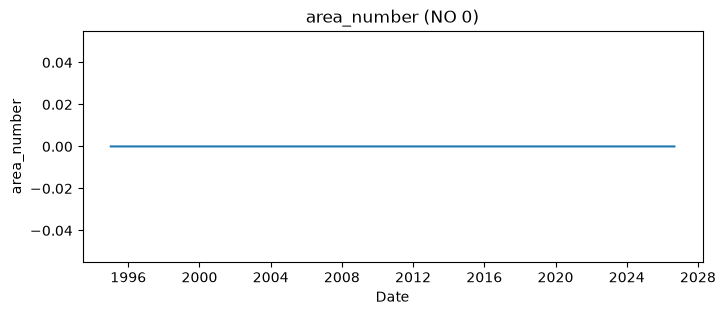

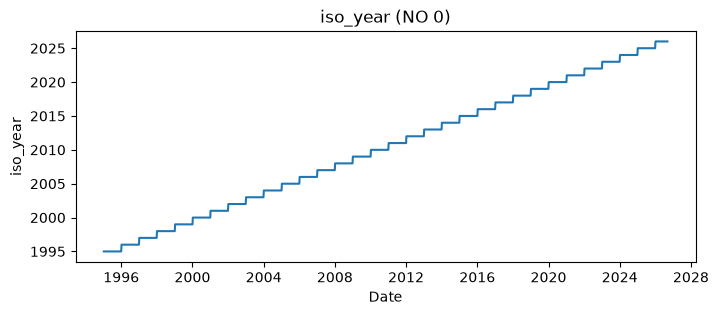

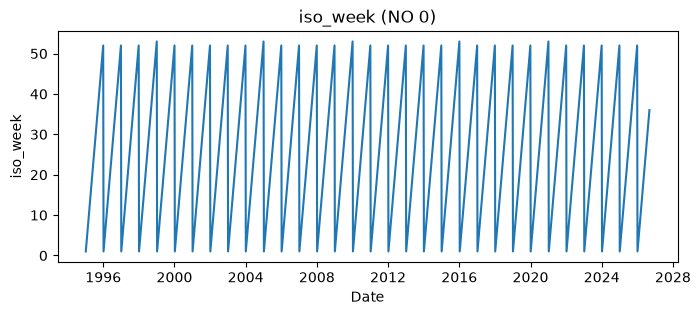

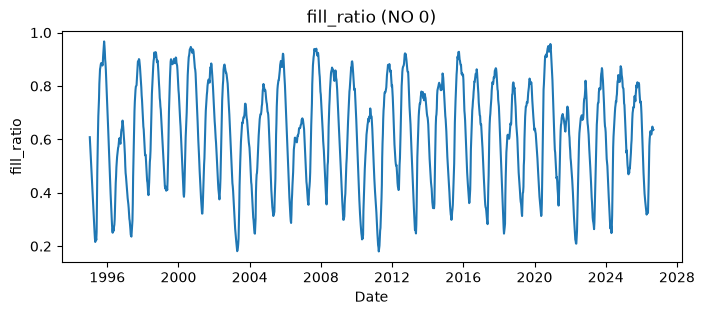

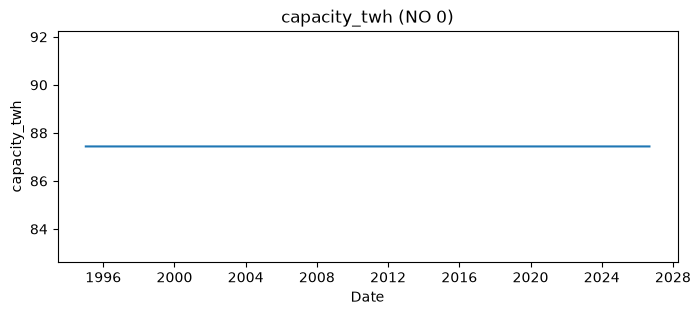

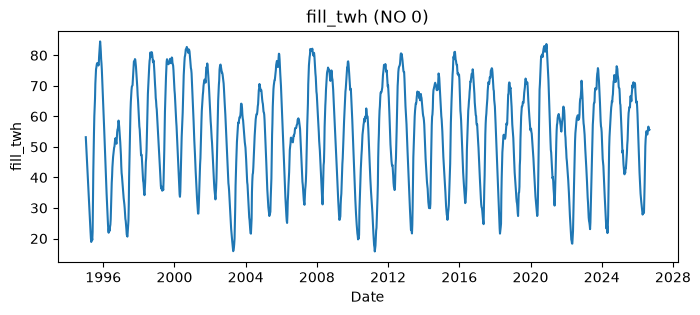

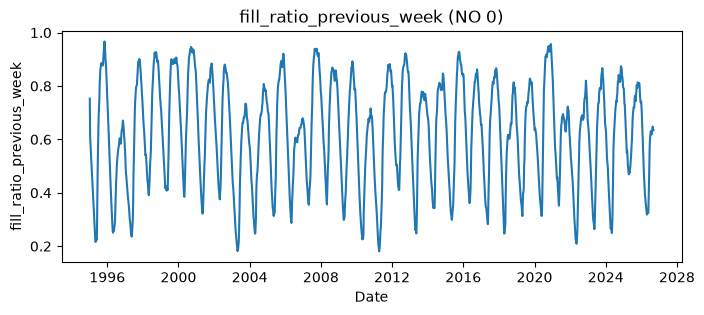

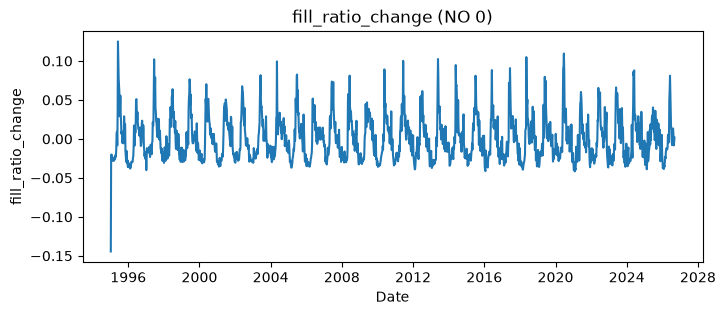

In [21]:
# Plot hver numeriske kolonne separat. En for area, med date på x-aksen
import matplotlib.pyplot as plt
area = 'NO 0' # Bytt til et annet område, f.eks EL 1
df_area = df[df['area'] == area]
numeric_cols = df_area.select_dtypes(include='number').columns
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    plt.plot(df_area['date'], df_area[col])
    plt.title(f'{col} ({area})')
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.show()

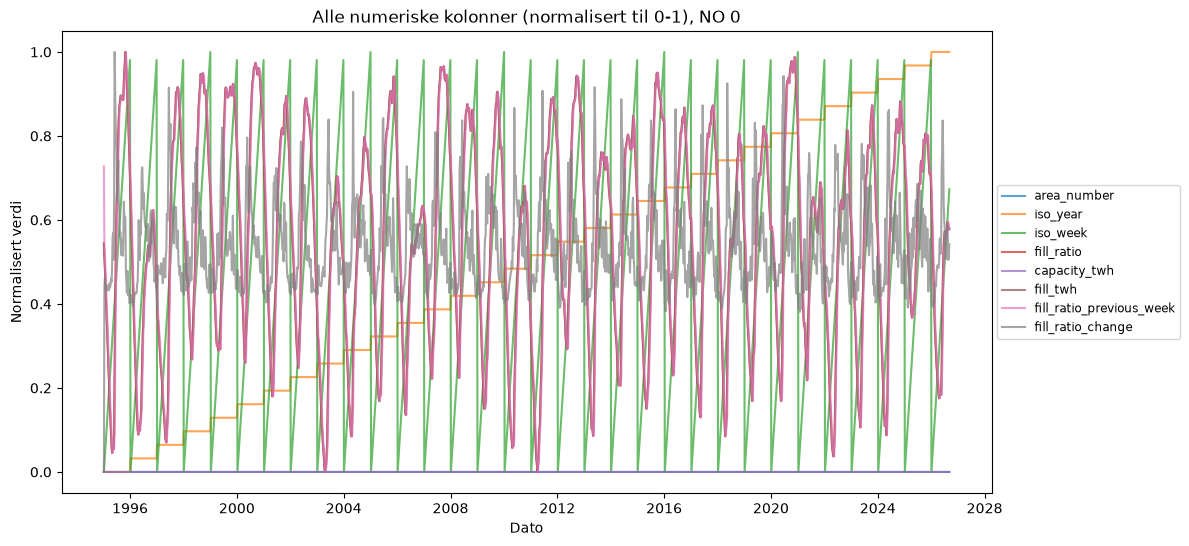

In [24]:
# Skaler hver numeriske kolonne til 0-1 med hele serien til området, slik at ulike skalaer kan dele én akse
col_min = df_area[numeric_cols].min()
col_range = df_area[numeric_cols].max() - col_min
# Kolonner som aldri endrer seg har spenn 0 (0/0 gir NaN), så de settes til 0
normalized = ((df_area[numeric_cols] - col_min) / col_range).fillna(0)

# Plott alle skalerte kolonner sammen
plt.figure(figsize=(12, 6))
for col in numeric_cols:
    plt.plot(df_area['date'], normalized[col], label=col, alpha=0.7)
plt.title(f'Alle numeriske kolonner (normalisert til 0-1), {area}')
plt.xlabel('Dato')
plt.ylabel('Normalisert verdi')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
plt.show()